In [1]:
import warnings
warnings.filterwarnings("ignore")
import torch

import pandas as pd
import numpy as np
import scanpy as sc
import os
import yaml
from pathlib import Path
from tqdm import tqdm


os.environ["CUDA_VISIBLE_DEVICES"] = "0"
#os.environ['R_HOME'] = 'D:/software/R/R-4.3.2'
#os.environ['R_USER'] = 'D:/software/anaconda/anaconda3/envs/pt20cu118/Lib/site-packages/rpy2'
from sklearn.decomposition import PCA

import STG3Net as MODEL

In [3]:
ROOT_PATH = Path('../../data/MBA-MBP')
DATA_NAME = 'Mouse_Brain_Anterior'
adata_anterior = sc.read_visium(ROOT_PATH / DATA_NAME, count_file=DATA_NAME + "_filtered_feature_bc_matrix.h5")
adata_anterior.var_names_make_unique()

spatial_a=pd.read_csv("../../data/MBA-MBP/Mouse_Brain_Anterior/spatial/tissue_positions_list.csv",
                    sep=",",header=None,na_filter=False,index_col=0)
adata_anterior.obs["x_array"]=spatial_a[2]
adata_anterior.obs["y_array"]=spatial_a[3]
adata_anterior.obs["x_pixel"]=spatial_a[4]
adata_anterior.obs["y_pixel"]=spatial_a[5]
adata_anterior.obs['boundary'] = 0
# adata_anterior.obs['x_pixel'] = adata_anterior.obsm['spatial'][:,0]
# adata_anterior.obs['y_pixel'] = adata_anterior.obsm['spatial'][:,1]
# make spot name unique
adata_anterior.obs_names = [x + '_anterior' for x in adata_anterior.obs_names]

# adata_anterior.layers['count'] = adata_anterior.X.toarray()
# sc.pp.normalize_total(adata_anterior, target_sum=1e6)
# sc.pp.highly_variable_genes(adata_anterior, flavor="seurat_v3", layer='count', n_top_genes=5000)
# adata_anterior = adata_anterior[:, adata_anterior.var['highly_variable'] == True]
# sc.pp.scale(adata_anterior)
# adata_anterior = adata_anterior[:, adata_anterior.var['highly_variable']]
adata_anterior

AnnData object with n_obs × n_vars = 2695 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [4]:
DATA_NAME = 'Mouse_Brain_Posterior'
adata_posterior = sc.read_visium(ROOT_PATH / DATA_NAME, count_file=DATA_NAME + "_filtered_feature_bc_matrix.h5")
adata_posterior.var_names_make_unique()

spatial_p=pd.read_csv("../../data/MBA-MBP/Mouse_Brain_Posterior/spatial/tissue_positions_list.csv",
                    sep=",",header=None,na_filter=False,index_col=0)
adata_posterior.obs["x_array"]=spatial_p[2]
adata_posterior.obs["y_array"]=spatial_p[3]
adata_posterior.obs["x_pixel"]=spatial_p[4]
adata_posterior.obs["y_pixel"]=spatial_p[5]
adata_posterior.obs['boundary'] = 0
# adata_posterior.obs['x_pixel'] = adata_posterior.obsm['spatial'][:,0]
# adata_posterior.obs['y_pixel'] = adata_posterior.obsm['spatial'][:,1]
# make spot name unique
adata_posterior.obs_names = [x + '_posterior' for x in adata_posterior.obs_names]

# adata_posterior.layers['count'] = adata_posterior.X.toarray()
# sc.pp.normalize_total(adata_posterior, target_sum=1e6)
# sc.pp.highly_variable_genes(adata_posterior, flavor="seurat_v3", layer='count', n_top_genes=5000)
# adata_posterior = adata_posterior[:, adata_posterior.var['highly_variable'] == True]
# sc.pp.scale(adata_posterior)
# adata_posterior = adata_posterior[:, adata_posterior.var['highly_variable']]
adata_posterior

AnnData object with n_obs × n_vars = 3355 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [5]:
obs_a = adata_anterior.obs
obs_p = adata_posterior.obs
# obs_p["x_pixel"]=obs_p["x_pixel"]-np.min(obs_p["x_pixel"])+np.min(obs_a["x_pixel"])
obs_p["y_pixel"] = obs_p["y_pixel"] - np.min(obs_p["y_pixel"]) + np.max(obs_a["y_pixel"]) - 150
# obs_p["y_pixel"] = obs_p["y_pixel"] - np.min(obs_p["y_pixel"]) + np.max(obs_a["y_pixel"]) + 1500

obs_a["boundary"] = 0
obs_p["boundary"] = 0

for i in list(set(obs_a['x_array'])):
    j = obs_a[obs_a['x_array'] == i].max()["y_array"]
    temp = obs_a[obs_a['x_array'] == i]
    temp = temp[temp['y_array'] == j].index
    obs_a.loc[temp, "boundary"] = 1

for i in list(set(obs_p['x_array'])):
    j = obs_p[obs_p['x_array'] == i].min()["y_array"]
    temp = obs_p[obs_p['x_array'] == i]
    temp = temp[temp['y_array'] == j].index
    obs_p.loc[temp, "boundary"] = 1

mean_a_y = obs_a[obs_a["boundary"] == 1]['x_pixel'].mean()
mean_p_y = obs_p[obs_p["boundary"] == 1]['x_pixel'].mean()
obs_p['x_pixel'] = obs_p['x_pixel'] + mean_a_y - mean_p_y

In [6]:
adata_anterior.obsm["spatial_aligned"] = adata_anterior.obs.loc[
adata_anterior.obs_names, ['x_pixel', "y_pixel"]].to_numpy()
adata_posterior.obsm["spatial_aligned"] = adata_posterior.obs.loc[
adata_posterior.obs_names, ['x_pixel', "y_pixel"]].to_numpy()

list_adata = [adata_anterior, adata_posterior]

In [7]:
import anndata as ad
pre_adata = ad.concat(list_adata, label="batch_name", keys=['anterior', 'posterior'])
pre_adata.obs["batch_name"] = pre_adata.obs["batch_name"].astype('category')
pre_adata

AnnData object with n_obs × n_vars = 6050 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary', 'batch_name'
    obsm: 'spatial', 'spatial_aligned'

In [8]:
slice_name_list = list(pre_adata.obs['batch_name'].unique())
slice_name_list

['anterior', 'posterior']

In [12]:
def mapping2int(string_array):
    mapping = {}
    result = []
    for string in string_array:
        if string not in mapping:
            mapping[string] = len(mapping)
        result.append(mapping[string])
    return result, mapping

def get_data(slice_name_list, config):
    global graph_dict
    #data_root = Path('../../data/MBA-MBP')
    result, mapping = mapping2int(slice_name_list)
    for i, proj_name in enumerate(slice_name_list):
        
        adata_tmp = pre_adata[pre_adata.obs['batch_name'] == slice_name_list[i]]
        #adata_tmp = sc.read_visium(data_root / proj_name, count_file=proj_name + "_filtered_feature_bc_matrix.h5")
        adata_tmp.var_names_make_unique()

        adata_tmp.obs['batch_name'] = proj_name
        adata_tmp.obs['slice_id'] = mapping[proj_name]

        ##### Load layer_guess label, if have
        # truth_path = "../../data/DLPFC/" + proj_name + '/' + 'manual_annotations.txt'
        # Ann_df = pd.read_csv(truth_path, sep='\t', header=None, index_col=0)
        # Ann_df.columns = ['Ground Truth']
        # adata_tmp.obs['layer_guess'] = Ann_df.loc[adata_tmp.obs_names, 'Ground Truth']
        # adata_tmp = adata_tmp[~pd.isnull(adata_tmp.obs['layer_guess'])]

        graph_dict_tmp = MODEL.graph_construction(adata_tmp, config['k_cutoff'])
        if proj_name == slice_name_list[0]:
            adata = adata_tmp
            graph_dict = graph_dict_tmp
            name = proj_name
            adata.obs['proj_name'] = proj_name
        else:
            var_names = adata.var_names.intersection(adata_tmp.var_names)
            adata = adata[:, var_names]
            adata_tmp = adata_tmp[:, var_names]
            adata_tmp.obs['proj_name'] = proj_name

            adata = adata.concatenate(adata_tmp)
            graph_dict = MODEL.combine_graph_dict(graph_dict, graph_dict_tmp)
            name = name + '_' + proj_name

    adata.layers['count'] = adata.X.toarray()
    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)
    sc.pp.normalize_total(adata, target_sum=1e6)
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=config['top_genes'])
    adata = adata[:, adata.var['highly_variable'] == True]
    sc.pp.scale(adata)

    adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
    adata.obsm['X_pca'] = adata_X
    return adata, graph_dict

In [13]:
with open('Config/Config_DLPFC.yaml', 'r', encoding='utf-8') as f:
    config = yaml.load(f.read(), Loader=yaml.FullLoader)

num_cluster = 32

adata, graph_dict = get_data(slice_name_list, config['data'])

In [14]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
net = MODEL.G3net(adata, graph_dict=graph_dict, device=device, config=config, num_cluster=num_cluster)

In [15]:
net.train(verbose=1)

Epoch 495 total loss=0.295 recon loss=0.367 tri loss=0.000 disc loss=0.379:  50%|████▉     | 497/1000 [00:17<00:18, 27.08it/s]R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


Epoch 495 total loss=0.295 recon loss=0.367 tri loss=0.000 disc loss=0.379:  50%|████▉     | 497/1000 [00:27<00:18, 27.08it/s]

Processing datasets anterior have 14136 nodes or edges


Epoch 500 total loss=0.853 recon loss=0.364 tri loss=0.561 disc loss=0.372:  50%|█████     | 501/1000 [00:34<12:45,  1.53s/it]

...

fitting ...
  |======================================================================| 100%
Processing datasets anterior have 27572 nodes or edges


Epoch 945 total loss=0.430 recon loss=0.391 tri loss=0.109 disc loss=0.461:  95%|█████████▍| 947/1000 [03:27<00:02, 20.71it/s]

Processing datasets posterior have 22478 nodes or edges


Epoch 965 total loss=0.423 recon loss=0.386 tri loss=0.108 disc loss=0.445:  96%|█████████▋| 965/1000 [03:29<00:07,  4.60it/s]

Stop trainning because of loss convergence


In [16]:
enc_rep, recon = net.process()
enc_rep = enc_rep.data.cpu().numpy()
recon = recon.data.cpu().numpy()
adata.obsm['latent'] = enc_rep
adata.obsm['recon'] = recon
print(adata)

AnnData object with n_obs × n_vars = 6050 × 2000
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary', 'batch_name', 'slice_id', 'proj_name', 'batch', 'Tmp_domain'
    var: 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg'
    obsm: 'spatial', 'spatial_aligned', 'X_pca', 'latent', 'recon'
    layers: 'count'


In [17]:
adata = net.clustering(adata, num_cluster=num_cluster, used_obsm='latent', key_added_pred='mclust', method='mclust', random_seed=666)

fitting ...
  |======================================================================| 100%


In [25]:
adata1 = adata[adata.obs['batch_name'] == 'anterior']
# sc.pl.spatial(adata1, img_key=None, color=['mclust'], title=[''],
#               legend_loc=None, legend_fontsize=12, show=False, frameon=False,
#               spot_size=100)

In [31]:
data_root = Path('../../data/MBA-MBP')

df_label = pd.read_csv(data_root / 'Mouse_Brain_Anterior' / 'manual_annotations.tsv', sep='\t',  index_col=0)
#转换index名称
index = [s + '_anterior-0' for s in df_label.index]
df_label.index = index
adata1.obs["layer_guess"] = df_label['ground_truth']

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

In [34]:
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
ARI = ari_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total ARI:{ARI}")

total ARI:0.3589903005767641


In [35]:
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
NMI = nmi_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total NMI:{NMI}")
AMI = ami_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total AMI:{AMI}")
ACC = 1/2 * (NMI + AMI)
print(f"total ACC:{ACC}")

total NMI:0.6565291033164236
total AMI:0.6285737418399858
total ACC:0.6425514225782047


In [36]:
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
HOM = hom_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total HOM:{HOM}")
COM = com_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total COM:{COM}")
V = 2 * ((HOM * COM) / (HOM + COM))
print(f"total V:{V}")

total HOM:0.6142963913864821
total COM:0.7049974915216071
total V:0.6565291033164236


[<Axes: xlabel='spatial1', ylabel='spatial2'>]

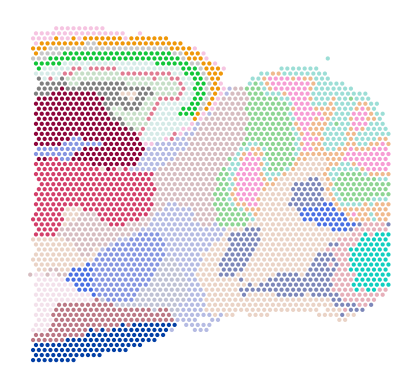

In [37]:
adata2 = adata[adata.obs['batch_name'] == 'posterior']
sc.pl.spatial(adata2, img_key=None, color=['mclust'], title=[''],
              legend_loc=None, legend_fontsize=12, show=False, frameon=False,
              spot_size=100)

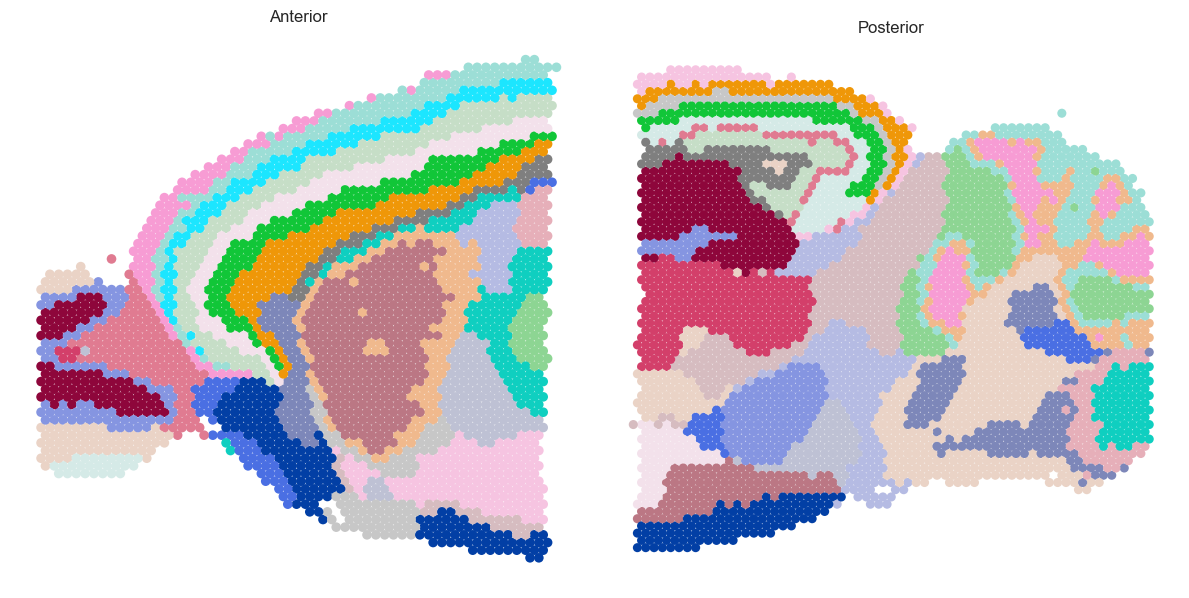

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 绘制第一个批次的空间图
sc.pl.spatial(adata1, ax=axes[0], img_key=None, color=['mclust'], title=['Anterior'],
              legend_loc=None, legend_fontsize=12, show=False, frameon=False,
              spot_size=150)

# 绘制第二个批次的空间图
sc.pl.spatial(adata2, ax=axes[1], img_key=None, color=['mclust'], title=['Posterior'],
              legend_loc=None, legend_fontsize=12, show=False, frameon=False,
              spot_size=150)

# 显示图像
plt.tight_layout()
plt.show()

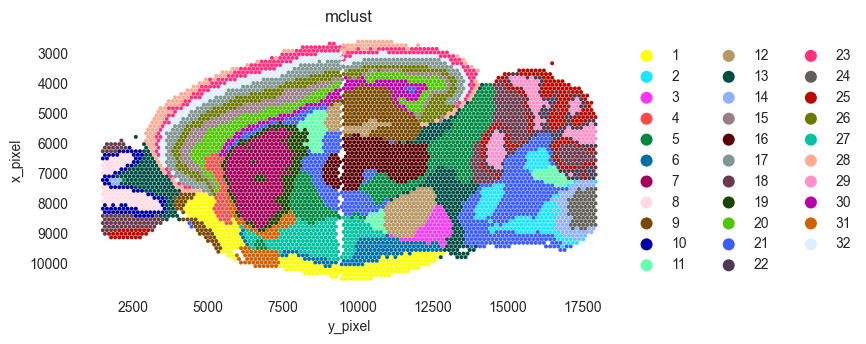

In [40]:
import matplotlib.pyplot as plt

plt.rcParams['axes.facecolor'] = 'white'  # 设置子图的背景颜色
plt.rcParams['figure.facecolor'] = 'white'  # 设置整张图的背景颜色

title = "SpaBatch"
subadata = adata[~adata.obs['mclust'].isna()]  # 删除 NaN
ax=sc.pl.scatter(subadata,alpha=1,x="y_pixel",y="x_pixel",color="mclust",show=False,size=200000/adata.shape[0])
ax.set_aspect('equal', 'box')
ax.axes.invert_yaxis()
plt.grid(False)